In [2]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import pickle
import time
from itertools import product

#### graphical
import matplotlib.pyplot as plt
import corner

import scipy.stats as st


In [48]:
df_full = pd.read_hdf('../grids/Chiara-dnufit.hdf5', key='df')

df_test = df_full.sample(10000)
#df_test = df_test[(df_test['FeH'] < -0.9)&(df_test['FeH']>-1.1)]

In [49]:
def massfromage(age):
    logage = np.log(age)
    return np.exp(-0.3*logage + 2.4)

In [50]:
df_test.columns

Index(['track_id', 'massini', 'zini', 'yini', 'alphaMLT', 'alphaFe', 'eta',
       'age', 'TAMS', 'logg', 'LPhot', 'Teff', 'FeH', 'numax', 'dnufit',
       'numaxAsf'],
      dtype='object')

/tmp/ipykernel_2543702/2427398321.py:2: RuntimeWarning: invalid value encountered in log
  logage = np.log(age)


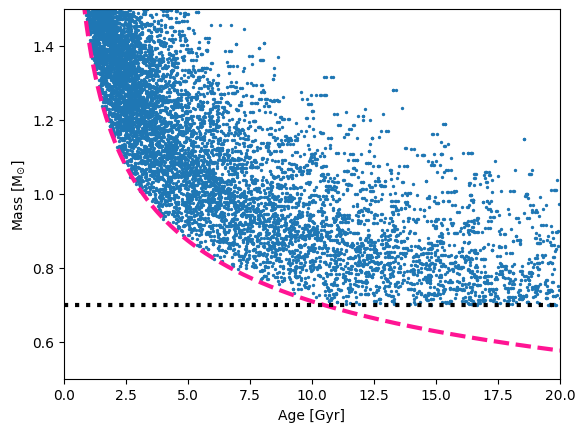

In [51]:
test_age = np.linspace(np.min(df_test['age']) - 3000, np.max(df_test['age']), 1000)

plt.scatter(df_test['age']/10**3, df_test['massini'],s = 2)
plt.plot(test_age/10**3, 1.02*massfromage(test_age,), color = 'deeppink', linestyle = '--', linewidth = 3)
#plt.plot(test_age/10**3, 1.55*massfromage(test_age) , color = 'deeppink', linewidth = 3, alpha = 0.5)
plt.plot(test_age/10**3, color = 'deeppink', linewidth = 3, alpha = 0.5)
plt.ylim(0.5, 1.5)
plt.xlim(0, 20)
plt.axhline(0.7, color = 'black', linewidth = 3, linestyle = 'dotted')
plt.xlabel('Age [Gyr]')
plt.ylabel(r'Mass [M$_{\odot}$]')
plt.savefig('./mass-age-scaling-simple.png', bbox_inches = 'tight', dpi = 150)

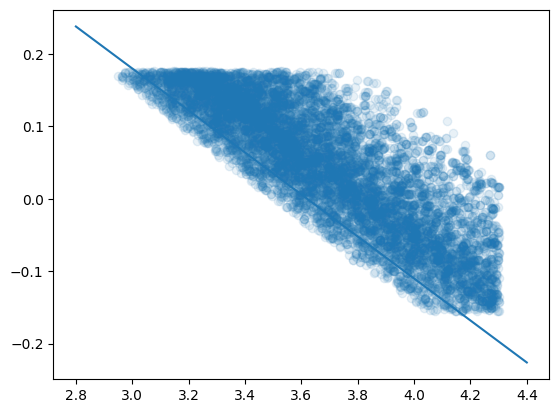

In [72]:
line = st.linregress(np.log10(df_test['age']), np.log10(df_test['massini']))

plt.scatter(np.log10(df_test['age']), np.log10(df_test['massini']), alpha = 0.1)
#plt.plot(np.linspace(2.8, 4.4), line.slope*np.linspace(2.8, 4.4) + line.intercept)
plt.plot(np.linspace(2.8, 4.4), -0.29*np.linspace(2.8, 4.4) + 1.05)

In [1]:
plt.scatter(np.log(df_test['age']), np.log(df_test['massini']), alpha = 0.1)
plt.plot(np.linspace(6.7, 10), -0.2*np.linspace(6.7, 10) + 2.4)
plt.plot(np.linspace(6.7, 10), -0.3*np.linspace(6.7, 10) + 3)

NameError: name 'plt' is not defined

In [16]:
line

LinregressResult(slope=np.float64(-0.23091248719461938), intercept=np.float64(0.8955805629018252), rvalue=np.float64(-0.8365219444415688), pvalue=np.float64(0.0), stderr=np.float64(0.0015126599465555798), intercept_stderr=np.float64(0.005608876038854365))